1. На основе учебного ноутбука проведите финальную подготовку данных. Иизмените количество сегментирующих классов с `16` на `5`.

2. Проведите суммарно не менее `10` экспериментов и визуализируйте их результаты (включая точность обучения сетей на одинаковом количестве эпох, например, на `7`):

  - изменив `filters` в сверточных слоях
  - изменив `kernel_size` в сверточных слоях
  - изменив активационную функцию в скрытых слоях с `relu` на `linear` или/и `selu`, `elu`.


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

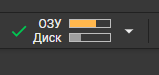



Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка

### Импорт библиотек

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
import gc
import gdown

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


### Загрузка датасета

грузим и распаковываем архив картинок

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
!unzip -q 'construction_256x192.zip'

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:15<00:00, 14.0MB/s]


In [ ]:
# Глобальные параметры

IMG_WIDTH = 192               # Ширина картинки
IMG_HEIGHT = 256              # Высота картинки
NUM_CLASSES = 16              # Задаем количество классов на изображении
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки

Загрузим оригинальные изображения (код из лекции):

In [ ]:
train_images = []
val_images = []

cur_time = time.time()

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original', filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

print('Обучающая выборка загружена. Время: ', round(time.time() - cur_time, 2), 'c')
print('Количество: ', len(train_images))

cur_time = time.time()

for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original', filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

print('Проверочная выборка загружена. Время: ', round(time.time() - cur_time, 2), 'c')
print('Количество: ', len(val_images))

Обучающая выборка загружена. Время:  0.6 c
Количество:  1900
Проверочная выборка загружена. Время:  0.01 c
Количество:  100


Загрузим сегментированные изображения (код из лекции):

In [ ]:
train_segments = []
val_segments = []

cur_time = time.time()

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')):
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment', filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

print('Обучающие маски загружены. Время: ', round(time.time() - cur_time, 2), 'c')
print('Количество: ', len(train_segments))

cur_time = time.time()

for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')):
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment', filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

print('Проверочные маски загружены. Время: ', round(time.time() - cur_time, 2), 'c')
print('Количество: ', len(val_segments))

Обучающие маски загружены. Время:  0.35 c
Количество:  1900
Проверочные маски загружены. Время:  0.02 c
Количество:  100


## Решение


## Цветовая карта для 5 классов и подготовка данных

In [ ]:
# Цвета для 5 классов
CLASS_COLORS_5 = [
    (0, 0, 0),       # фон
    (100, 0, 0),     # класс 1
    (0, 100, 0),     # класс 2
    (0, 0, 100),     # класс 3
    (100, 100, 0),   # класс 4
]
NUM_CLASSES = 5

def segments_to_class_map(seg_list, class_colors, num_classes=5):
    h, w = seg_list[0].size[1], seg_list[0].size[0]
    result = np.zeros((len(seg_list), h, w), dtype=np.int64)

    for i, seg in enumerate(seg_list):
        seg_arr = np.array(seg)
        for class_idx, color in enumerate(class_colors):
            mask = np.all(seg_arr == color, axis=-1)
            result[i, mask] = class_idx
    return result

# X как float32 нормализованные [0,1]
x_train = np.array([np.array(img, dtype=np.float32) / 255.0 for img in train_images])
x_val = np.array([np.array(img, dtype=np.float32) / 255.0 for img in val_images])

# Y как индексы классов
y_train = segments_to_class_map(train_segments, CLASS_COLORS_5, NUM_CLASSES)
y_val = segments_to_class_map(val_segments, CLASS_COLORS_5, NUM_CLASSES)

x_train = np.transpose(x_train, (0, 3, 1, 2))
x_val = np.transpose(x_val, (0, 3, 1, 2))

print(f"x_train: {x_train.shape} dtype={x_train.dtype}")
print(f"y_train: {y_train.shape} dtype={y_train.dtype}")

del train_images, val_images, train_segments, val_segments
gc.collect()

x_train: (1900, 3, 192, 256) dtype=float32
y_train: (1900, 192, 256) dtype=int64


0

## Dataset и DataLoader

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, images, masks):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.masks = torch.tensor(masks, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

# Создаем датасеты
train_dataset = SegmentationDataset(x_train, y_train)
val_dataset = SegmentationDataset(x_val, y_val)

# DataLoader'ы
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 119, Val batches: 7


## U-Net архитектура

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, activation='relu'):
        super(DoubleConv, self).__init__()

        if activation == 'relu':
            act = nn.ReLU(inplace=True)
        elif activation == 'elu':
            act = nn.ELU(inplace=True)
        elif activation == 'selu':
            act = nn.SELU(inplace=True)
        elif activation == 'linear':
            act = nn.Identity()
        else:
            act = nn.ReLU(inplace=True)

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(out_channels),
            act,
            nn.Conv2d(out_channels, out_channels, kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm2d(out_channels),
            act
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, activation='relu'):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, kernel_size, activation)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, activation='relu'):
        super(Up, self).__init__()

        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels, kernel_size, activation)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=5, filters_base=24, kernel_size=3, activation='relu'):
        super(UNet, self).__init__()

        self.inc = DoubleConv(n_channels, filters_base, kernel_size, activation)
        self.down1 = Down(filters_base, filters_base*2, kernel_size, activation)
        self.down2 = Down(filters_base*2, filters_base*4, kernel_size, activation)
        self.down3 = Down(filters_base*4, filters_base*8, kernel_size, activation)
        self.down4 = Down(filters_base*8, filters_base*16, kernel_size, activation)

        self.up1 = Up(filters_base*16, filters_base*8, kernel_size, activation)
        self.up2 = Up(filters_base*8, filters_base*4, kernel_size, activation)
        self.up3 = Up(filters_base*4, filters_base*2, kernel_size, activation)
        self.up4 = Up(filters_base*2, filters_base, kernel_size, activation)

        self.outc = nn.Conv2d(filters_base, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits

def create_unet(n_classes=5, filters_base=24, kernel_size=3, activation='relu'):
    return UNet(n_channels=3, n_classes=n_classes, filters_base=filters_base,
                kernel_size=kernel_size, activation=activation)

## Метрика IoU и функция обучения

In [ ]:
def iou_score(pred, target, num_classes=5):
    ious = []
    pred = torch.argmax(pred, dim=1)  # (B, H, W)

    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)

        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append((intersection / (union + 1e-7)).item())

    # Средний IoU по всем классам
    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    return np.mean(valid_ious) if valid_ious else 0.0

def train_and_evaluate(name, filters_base, kernel_size, activation, epochs=7):
    print(f"\n{'='*60}")
    print(f"Эксперимент: {name} (f={filters_base}, k={kernel_size}, act={activation})")
    print(f"{'='*60}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = create_unet(n_classes=NUM_CLASSES, filters_base=filters_base,
                        kernel_size=kernel_size, activation=activation)
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [], 'train_acc': [], 'train_iou': [],
        'val_loss': [], 'val_acc': [], 'val_iou': []
    }

    for epoch in range(epochs):
        # Обучение
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        train_iou_sum = 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == masks).sum().item()
            train_total += masks.numel()
            train_iou_sum += iou_score(outputs, masks, NUM_CLASSES)

        # Валидация
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_iou_sum = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == masks).sum().item()
                val_total += masks.numel()
                val_iou_sum += iou_score(outputs, masks, NUM_CLASSES)

        train_loss_avg = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_iou = train_iou_sum / len(train_loader)

        val_loss_avg = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_iou = val_iou_sum / len(val_loader)

        history['train_loss'].append(train_loss_avg)
        history['train_acc'].append(train_acc)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(val_loss_avg)
        history['val_acc'].append(val_acc)
        history['val_iou'].append(val_iou)

        print(f"Epoch {epoch+1}/{epochs} - "
              f"loss: {train_loss_avg:.4f}, acc: {train_acc:.4f}, iou: {train_iou:.4f} - "
              f"val_loss: {val_loss_avg:.4f}, val_acc: {val_acc:.4f}, val_iou: {val_iou:.4f}")

    result = {
        'name': name,
        'filters': filters_base,
        'kernel': kernel_size,
        'activation': activation,
        'history': history,
        'model': model
    }
    return result

## Функции визуализации графиков обучения и визуализации предсказаний

In [ ]:
def plot_results(results, epochs=7):
    plt.figure(figsize=(14, 8))

    plt.subplot(2, 2, 1)
    for r in results:
        plt.plot(range(1, epochs+1), r['history']['val_acc'], label=r['name'], marker='o')
    plt.title('val_accuracy')
    plt.xlabel('Эпоха')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    for r in results:
        plt.plot(range(1, epochs+1), r['history']['val_iou'], label=r['name'], marker='s')
    plt.title('val_iou')
    plt.xlabel('Эпоха')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 3)
    for r in results:
        plt.plot(range(1, epochs+1), r['history']['train_loss'], label=r['name'], marker='^')
    plt.title('train_loss')
    plt.xlabel('Эпоха')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 4)
    for r in results:
        plt.plot(range(1, epochs+1), r['history']['val_loss'], label=r['name'], marker='d')
    plt.title('val_loss')
    plt.xlabel('Эпоха')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def predict_and_visualize(model, x_val, y_val, idx=0):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    with torch.no_grad():
        img = torch.tensor(x_val[idx:idx+1]).to(device)
        pred = model(img)
        pred_mask = torch.argmax(pred, dim=1).cpu().numpy()[0]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(np.transpose(x_val[idx], (1, 2, 0)))
    axes[0].set_title('Оригинал')
    axes[0].axis('off')

    axes[1].imshow(y_val[idx], cmap='tab10')
    axes[1].set_title('Истинная маска')
    axes[1].axis('off')

    axes[2].imshow(pred_mask, cmap='tab10')
    axes[2].set_title('Предсказание')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## Список экспериментов

In [ ]:
experiments = [
    # Изменение фильтров
    ("Filters_16", 16, 3, "relu"),
    ("Base_24x3_relu", 24, 3, "relu"),
    ("Filters_32", 32, 3, "relu"),

    # Изменение kernel_size
    ("Kernel_5", 24, 5, "relu"),
    ("Kernel_7", 24, 7, "relu"),

    # Изменение активации
    ("Act_linear", 24, 3, "linear"),
    ("Act_selu", 24, 3, "selu"),
    ("Act_elu", 24, 3, "elu"),

    # Комбинированные (filters=24 вместо 32 для снижения нагрузки)
    ("Comb_F16_K5_elu", 16, 5, "elu"),
    ("Comb_F24_K7_selu", 24, 7, "selu"),
]
EPOCHS = 7

## Обучение всех экспериментов

In [ ]:
all_results = []

for name, f, k, act in experiments:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    result = train_and_evaluate(name, f, k, act, EPOCHS)
    all_results.append(result)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"\nЭксперимент '{name}' завершен\n")
    print("="*60)


Эксперимент: Filters_16 (f=16, k=3, act=relu)
Epoch 1/7 - loss: 1.4625, acc: 0.4182, iou: 0.1769 - val_loss: 1.2813, val_acc: 0.6192, val_iou: 0.2722
Epoch 2/7 - loss: 1.1763, acc: 0.7096, iou: 0.3247 - val_loss: 1.1784, val_acc: 0.6689, val_iou: 0.2980
Epoch 3/7 - loss: 1.0418, acc: 0.7649, iou: 0.3634 - val_loss: 1.1054, val_acc: 0.6987, val_iou: 0.3195
Epoch 4/7 - loss: 0.9411, acc: 0.7833, iou: 0.3795 - val_loss: 1.0449, val_acc: 0.7044, val_iou: 0.3278
Epoch 5/7 - loss: 0.8576, acc: 0.7949, iou: 0.3915 - val_loss: 0.9939, val_acc: 0.7035, val_iou: 0.3263
Epoch 6/7 - loss: 0.7821, acc: 0.8061, iou: 0.3992 - val_loss: 0.9291, val_acc: 0.7220, val_iou: 0.3388
Epoch 7/7 - loss: 0.7182, acc: 0.8151, iou: 0.4071 - val_loss: 0.9079, val_acc: 0.7103, val_iou: 0.3344

Эксперимент 'Filters_16' завершен


Эксперимент: Base_24x3_relu (f=24, k=3, act=relu)
Epoch 1/7 - loss: 1.4956, acc: 0.3142, iou: 0.1575 - val_loss: 1.3351, val_acc: 0.5859, val_iou: 0.2774
Epoch 2/7 - loss: 1.1849, acc: 0.7

## Итоговая таблица результатов

In [ ]:
print("\n" + "="*80)
print(f"{'Эксперимент':<22} {'Val Acc':<12} {'Val IoU':<12}")
print("="*80)

for r in all_results:
    val_acc = r['history']['val_acc'][-1]
    val_iou = r['history']['val_iou'][-1]
    print(f"{r['name']:<22} {val_acc:<12.4f} {val_iou:<12.4f}")

print("="*80)

best = max(all_results, key=lambda x: x['history']['val_iou'][-1])
print(f"\n Лучшая: {best['name']} (Val IoU = {best['history']['val_iou'][-1]:.4f})")


Эксперимент            Val Acc      Val IoU     
Filters_16             0.7103       0.3344      
Base_24x3_relu         0.7279       0.3717      
Filters_32             0.7261       0.3649      
Kernel_5               0.7157       0.3343      
Kernel_7               0.7330       0.3618      
Act_linear             0.6765       0.3089      
Act_selu               0.7243       0.3371      
Act_elu                0.7291       0.3594      
Comb_F16_K5_elu        0.7402       0.3510      
Comb_F24_K7_selu       0.7336       0.3522      

 Лучшая: Base_24x3_relu (Val IoU = 0.3717)


## Визуализация лучшей модели

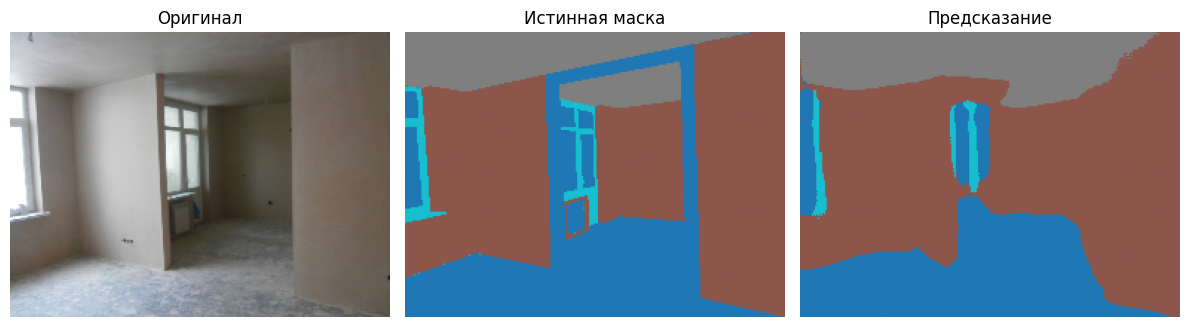

In [ ]:
best_model = best['model']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = best_model.to(device)

predict_and_visualize(best_model, x_val, y_val, idx=0)